# Multi-survey CMDs: LSST + Roman

This notebook demonstrates the `StreamInjector` multi-survey workflow by injecting
a mock stellar stream into **both LSST Year 4** and **Roman DC2** surveys simultaneously.
The same physical stars carry photometry from both instruments, enabling cross-survey
colour-magnitude diagrams (CMDs).

Three CMDs are shown:
1. **LSST yr4**: (*g* − *r*) vs *r*
2. **Roman DC2**: (*F106*_obs − *F158*_obs) vs *F158*_obs — fully observed both bands
3. **Cross-survey**: (*g*_LSST − *F158*_Roman) vs *F158*

Each panel overlays *true* (noiseless) magnitudes in grey with *observed*
(noise- and selection-function-convolved) magnitudes in colour.

:::{note}
**Roman survey used here.** The Roman DC2 survey (`roman_dc2`) covers RA ≈ 51–56°,
Dec ≈ −38° to −42° — a small synthetic footprint derived from the Roman-Rubin DC2
simulation (Troxel et al. 2023). It carries three bands (F106, F129, F158) with full
selection-function products for both F106 and F158, enabling a fully-observed
two-band Roman CMD. The Roman HLWAS wide-area survey (`roman_hlwas_wide`) is
F158-only and cannot support a two-band Roman CMD; `roman_dc2` is used here
specifically to illustrate the F106−F158 colour axis.
:::

:::{note}
**Shared footprint.** The stream stars are pre-placed in the DC2 region
(RA 52–55°, Dec −41.5° to −38.5°, centred at roughly RA 53.5°, Dec −40°).
Both surveys have valid magnitude-limit maps across this area (LSST yr4 covers
the full extragalactic sky; Roman DC2 is defined there). Pre-supplying `ra`/`dec`
avoids the great-circle-frame search, which is unreliable for a small footprint.
:::


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from streamobs.observed import StreamInjector

## Build the multi-survey injector

A single `StreamInjector` instance handles both LSST yr4 and Roman DC2.
The column namespace for each survey is `{name}_{release}`:
- LSST Year 4 → `lsst_yr4`
- Roman DC2  → `roman_dc2`

In [2]:
injector = StreamInjector(
    [
        {"survey": "lsst",  "release": "yr4"},
        {"survey": "roman", "release": "dc2"},
    ],
    verbose=False,
)

print("Surveys loaded:", list(injector.surveys.keys()))
print("Primary survey:", injector.primary_namespace)

/astro/store/shire/pferguso/software/streamobs/streamobs/surveys.py:1090: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  survey.maglim_maps[band] = hp.read_map(full_path, verbose=False)


Surveys loaded: ['lsst_yr4', 'roman_dc2']
Primary survey: lsst_yr4


## Stream model configuration

The stream is an old, metal-poor population (age 12 Gyr, Z = 0.0006) placed at a
distance modulus of 16.8 mag (~22 kpc). At this distance the main-sequence
turn-off falls at *r* ≈ 21–22 (within LSST reach) and *F158* ≈ 20–21
(well above Roman DC2 depth).

The isochrone is defined for **both surveys at once** via the `surveys:` mapping.
ugali Roman band names are uppercase (`F106`, `F158`); the keys must match the
survey namespace so the injector can route true-magnitude columns correctly.

In [3]:
NSTARS      = 3000
DIST_MOD    = 16.8   # distance modulus (mag) -> ~22 kpc
SEED        = 42

stream_config = {
    "nstars": NSTARS,
    "density": {"type": "Uniform", "xmin": -5.0, "xmax": 5.0},
    "track": {
        "center": {"type": "Constant", "value": 0.0},
        "spread": {"type": "Constant", "value": 0.2},
        "sampler": "Gaussian",
    },
    "distance_modulus": {
        "center": {"type": "Constant", "value": DIST_MOD},
        "spread": {"type": "Constant", "value": 0.0},
    },
    "isochrone": {
        "name": "Marigo2017",
        "age":  12.0,    # Gyr
        "z":    0.0006,  # metallicity
        "surveys": {
            # Key = column namespace; inner survey = ugali filter set
            "lsst_yr4":  {"survey": "lsst",  "band_1": "g",    "band_2": "r"},
            "roman_dc2": {"survey": "roman", "band_1": "F106", "band_2": "F158"},
        },
    },
}

## Place the stream in the Roman DC2 footprint

Roman DC2 covers only a small patch (RA 51–56°, Dec −38° to −42°). To guarantee
both surveys' magnitude-limit maps are finite at every star position, we
pre-assign `ra`/`dec` directly within this region — skipping the great-circle
frame search, which can fail for such a small footprint.

In [4]:
rng = np.random.default_rng(SEED)

# Uniformly scatter stars within the DC2 patch (RA 52-55 deg, Dec -41.5 to -38.5 deg)
ra  = rng.uniform(52.0, 55.0, NSTARS)
dec = rng.uniform(-41.5, -38.5, NSTARS)
input_catalog = pd.DataFrame({"ra": ra, "dec": dec})

print(f"Input: {len(input_catalog)} stars, RA {ra.min():.1f}-{ra.max():.1f} deg,"
      f" Dec {dec.min():.1f}-{dec.max():.1f} deg")

Input: 3000 stars, RA 52.0-55.0 deg, Dec -41.5--38.5 deg


## Step 1 — Sample true magnitudes from the shared isochrone

`complete_data` draws **one set of stellar masses** and interpolates those masses
into every survey's filter set, so each star's LSST and Roman photometry describe
the same physical object.  We request the Roman bands using ugali's uppercase
notation (`F106`, `F158`) — the resulting column names are
`roman_F106_true` and `roman_F158_true`.

In [5]:
catalog_true = injector.complete_data(
    input_catalog,
    bands={"lsst_yr4": ["g", "r"], "roman_dc2": ["F106", "F158"]},
    stream_config=stream_config,
    dist=DIST_MOD,
    seed=SEED,
    verbose=False,
)

true_cols = [c for c in catalog_true.columns if c.endswith("_true")]
print("True-magnitude columns:", true_cols)

True-magnitude columns: ['lsst_g_true', 'lsst_r_true', 'roman_F106_true', 'roman_F158_true']


## Step 2 — Inject observational effects

`inject` applies photometric noise and the survey selection function to produce
observed magnitudes. We now inject **both Roman DC2 bands** (`F106` and `F158`),
since the config wires `maglim_map_F106` and `maglim_map_F158` for `roman_dc2`.

- LSST yr4: `g` and `r`
- Roman DC2: `F106` and `F158`

The Roman DC2 detection flag (`roman_dc2_flag_observed`) is driven by F158
(the primary detection band). Observed colours (`F106_obs − F158_obs`) may be
available for a smaller subset of Roman-detected stars because F106 is shallower
for red sources — that subset is masked and counted below.

In [6]:
catalog_obs = injector.inject(
    catalog_true,
    bands={"lsst_yr4": ["g", "r"], "roman_dc2": ["F106", "F158"]},
    dist=DIST_MOD,
    seed=SEED,
    verbose=False,
)

lsst_det  = catalog_obs["lsst_yr4_flag_observed"]
roman_det = catalog_obs["roman_dc2_flag_observed"]
both_det  = lsst_det & roman_det

print(f"Stars with LSST yr4 detection:   {lsst_det.sum():4d} / {NSTARS}")
print(f"Stars with Roman DC2 detection:  {roman_det.sum():4d} / {NSTARS}")
print(f"Stars detected by both surveys:  {both_det.sum():4d} / {NSTARS}")

Stars with LSST yr4 detection:    468 / 3000
Stars with Roman DC2 detection:  1163 / 3000
Stars detected by both surveys:   390 / 3000


/astro/store/shiren/conda-envs/stream_team/envs/streamobs/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/astro/store/shiren/conda-envs/stream_team/envs/streamobs/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/astro/store/shiren/conda-envs/stream_team/envs/streamobs/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/astro/store/shiren/conda-envs/stream_team/envs/streamobs/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Colour-magnitude diagrams

Three CMDs with true photometry (grey, faint) overlaid by observed photometry
(coloured). Detected stars only are shown in the observed panels.

Verified output column names:
- `lsst_g_true`, `lsst_yr4_g_obs`
- `lsst_r_true`, `lsst_yr4_r_obs`
- `roman_F106_true`, `roman_dc2_F106_obs`
- `roman_F158_true`, `roman_dc2_F158_obs`

The Roman DC2 observed panel uses **fully observed** magnitudes for both bands
(`roman_dc2_F106_obs − roman_dc2_F158_obs`). Stars where the noisy F106 flux
went negative are recorded as `"BAD_MAG"` and are excluded from the colour axis,
so the observed Roman sample may be smaller than the F158-detected count — that
is physical (F106 is shallower for red MS stars).

Roman DC2 F158-detected:         1163
Roman DC2 obs-colour valid (both bands finite): 1163


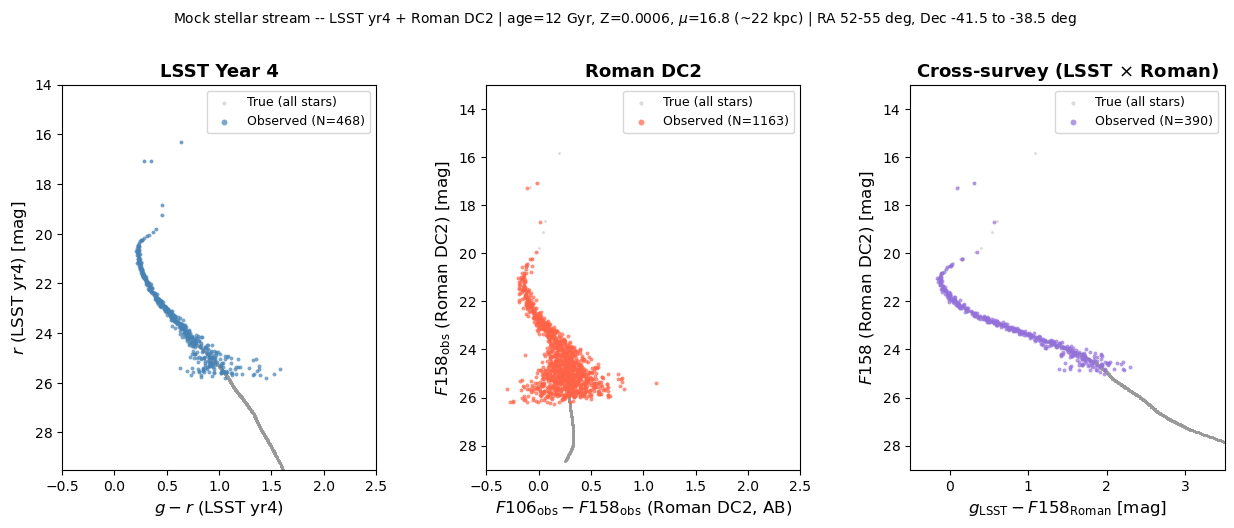

Figure saved.


In [7]:
# -- Extract photometry columns -----------------------------------------------
# LSST yr4 -- true
g_true = catalog_obs["lsst_g_true"]
r_true = catalog_obs["lsst_r_true"]
# LSST yr4 -- observed (detected only)
g_obs  = catalog_obs.loc[lsst_det, "lsst_yr4_g_obs"]
r_obs  = catalog_obs.loc[lsst_det, "lsst_yr4_r_obs"]

# Roman DC2 -- true (note: F106/F158 uppercase from ugali isochrone)
f106_true = catalog_obs["roman_F106_true"]
f158_true = catalog_obs["roman_F158_true"]

# Roman DC2 -- observed (both bands); coerce BAD_MAG strings to NaN, require valid pair
f106_obs_all = pd.to_numeric(catalog_obs["roman_dc2_F106_obs"], errors="coerce")
f158_obs_all = pd.to_numeric(catalog_obs["roman_dc2_F158_obs"], errors="coerce")
roman_obs_ok = roman_det & f106_obs_all.notna() & f158_obs_all.notna()
f106_obs = f106_obs_all[roman_obs_ok]
f158_obs = f158_obs_all[roman_obs_ok]

print(f"Roman DC2 F158-detected:         {roman_det.sum():4d}")
print(f"Roman DC2 obs-colour valid (both bands finite): {roman_obs_ok.sum():4d}")

# Cross-survey (stars detected by both)
g_obs_both    = catalog_obs.loc[both_det, "lsst_yr4_g_obs"]
f158_obs_both = catalog_obs.loc[both_det, "roman_dc2_F158_obs"]

# -- Plot settings ------------------------------------------------------------
TRUE_KW = dict(s=4, color="0.6", alpha=0.35, linewidths=0, label="True (all stars)")
OBS_KW  = dict(s=8, alpha=0.70, linewidths=0)

SURVEY_COLORS = {"lsst": "steelblue", "roman": "tomato", "cross": "mediumpurple"}

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# -- CMD 1: LSST yr4 (g - r) vs r ---------------------------------------------
ax1 = fig.add_subplot(gs[0])
ax1.scatter(g_true - r_true, r_true, **TRUE_KW)
ax1.scatter(g_obs - r_obs, r_obs,
            color=SURVEY_COLORS["lsst"],
            label=f"Observed (N={lsst_det.sum()})",
            **OBS_KW)
ax1.set_xlabel(r"$g - r$ (LSST yr4)", fontsize=12)
ax1.set_ylabel(r"$r$ (LSST yr4) [mag]", fontsize=12)
ax1.set_title("LSST Year 4", fontsize=13, fontweight="bold")
ax1.set_xlim(-0.5, 2.5)
ax1.set_ylim(29.5, 14.0)
ax1.legend(fontsize=9, markerscale=1.5)
ax1.tick_params(labelsize=10)

# -- CMD 2: Roman DC2 (F106 - F158) vs F158 -- fully observed both bands ------
ax2 = fig.add_subplot(gs[1])
ax2.scatter(f106_true - f158_true, f158_true, **TRUE_KW)
ax2.scatter(f106_obs - f158_obs, f158_obs,
            color=SURVEY_COLORS["roman"],
            label=f"Observed (N={int(roman_obs_ok.sum())})",
            **OBS_KW)
ax2.set_xlabel(r"$F106_{\rm obs} - F158_{\rm obs}$ (Roman DC2, AB)", fontsize=12)
ax2.set_ylabel(r"$F158_{\rm obs}$ (Roman DC2) [mag]", fontsize=12)
ax2.set_title("Roman DC2", fontsize=13, fontweight="bold")
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(29.0, 13.0)
ax2.legend(fontsize=9, markerscale=1.5)
ax2.tick_params(labelsize=10)

# -- CMD 3: cross-survey (g_LSST - F158_Roman) vs F158 -----------------------
ax3 = fig.add_subplot(gs[2])
ax3.scatter(g_true - f158_true, f158_true, **TRUE_KW)
ax3.scatter(g_obs_both - f158_obs_both, f158_obs_both,
            color=SURVEY_COLORS["cross"],
            label=f"Observed (N={both_det.sum()})",
            **OBS_KW)
ax3.set_xlabel(r"$g_{\rm LSST} - F158_{\rm Roman}$ [mag]", fontsize=12)
ax3.set_ylabel(r"$F158$ (Roman DC2) [mag]", fontsize=12)
ax3.set_title(r"Cross-survey (LSST $\times$ Roman)", fontsize=13, fontweight="bold")
ax3.set_xlim(-0.5, 3.5)
ax3.set_ylim(29.0, 13.0)
ax3.legend(fontsize=9, markerscale=1.5)
ax3.tick_params(labelsize=10)

fig.suptitle(
    rf"Mock stellar stream -- LSST yr4 + Roman DC2 "
    rf"| age=12 Gyr, Z=0.0006, $\mu$={DIST_MOD} (~22 kpc) "
    rf"| RA 52-55 deg, Dec -41.5 to -38.5 deg",
    fontsize=10, y=1.03,
)

plt.savefig("multisurvey_cmd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Summary

The multi-survey injector produced the following output column names:

| Survey | Band | True column | Observed column |
|---|---|---|---|
| LSST yr4 | g | `lsst_g_true` | `lsst_yr4_g_obs` |
| LSST yr4 | r | `lsst_r_true` | `lsst_yr4_r_obs` |
| Roman DC2 | F106 | `roman_F106_true` | `roman_dc2_F106_obs` |
| Roman DC2 | F158 | `roman_F158_true` | `roman_dc2_F158_obs` |

**Detection flags:**
- `lsst_yr4_flag_observed` — passed LSST completeness + photo-error cut
- `roman_dc2_flag_observed` — passed Roman DC2 F158 completeness + detection efficiency

**Roman DC2 CMD colour axis:** uses `roman_dc2_F106_obs − roman_dc2_F158_obs`
(fully observed). Stars where the noisy F106 flux went negative are stored as
`"BAD_MAG"` and excluded; the observed colour sample is a subset of
`roman_dc2_flag_observed` stars.